In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

print("EquiLens data environment ready!")

EquiLens data environment ready!


In [3]:
stock=yf.Ticker("AAPL")
data=stock.history(period='1y')
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-09-09 00:00:00-04:00,236.127759,237.901207,232.501156,233.487518,66313900,0.0,0.0
2025-09-10 00:00:00-04:00,231.335457,231.564607,225.118417,225.955322,83440800,0.0,0.0
2025-09-11 00:00:00-04:00,226.045010,229.601863,225.815845,229.183411,50208600,0.0,0.0
2025-09-12 00:00:00-04:00,228.376401,233.646925,228.177140,233.208557,55824200,0.0,0.0
2025-09-15 00:00:00-04:00,236.127756,237.313379,234.165005,235.828857,42699500,0.0,0.0


In [4]:
print("Shape:",data.shape)
print("Columns:",data.columns.tolist())

Shape: (251, 7)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


In [5]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-09-09 00:00:00-04:00 to 2026-09-08 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          251 non-null    float64
 1   High          251 non-null    float64
 2   Low           251 non-null    float64
 3   Close         251 non-null    float64
 4   Volume        251 non-null    int64  
 5   Dividends     251 non-null    float64
 6   Stock Splits  251 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.7 KB


In [6]:
print("Start Date:",data.index.min())
print("End Date:",data.index.max())
print("trading days:",len(data))
print("missing values:",data.isna().sum().sum())

Start Date: 2025-09-09 00:00:00-04:00
End Date: 2026-09-08 00:00:00-04:00
trading days: 251
missing values: 0


In [7]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02,251.000000,251.0
mean,277.736935,280.842341,275.023049,278.025082,4.949124e+07,0.004223,0.0
std,24.991318,25.531630,24.788850,25.290132,2.268670e+07,0.033258,0.0
min,226.045010,229.601863,225.118417,225.955322,1.791060e+07,0.000000,0.0
25%,258.093490,260.669801,255.569156,258.531708,3.828785e+07,0.000000,0.0
50%,271.600701,274.450243,269.167338,271.655243,4.501530e+07,0.000000,0.0
75%,297.888078,301.594893,295.245367,298.662415,5.251820e+07,0.000000,0.0
max,339.736982,344.273097,337.059318,339.786926,2.617755e+08,0.270000,0.0


In [8]:
data["Daily_Return"] = data["Close"].pct_change()

data[["Close", "Daily_Return"]].head(10)

,Close,Daily_Return
Date,,
2025-09-09 00:00:00-04:00,233.487518,NaN
2025-09-10 00:00:00-04:00,225.955322,-0.032260
2025-09-11 00:00:00-04:00,229.183411,0.014286
2025-09-12 00:00:00-04:00,233.208557,0.017563
2025-09-15 00:00:00-04:00,235.828857,0.011236
2025-09-16 00:00:00-04:00,237.273514,0.006126
2025-09-17 00:00:00-04:00,238.110443,0.003527
2025-09-18 00:00:00-04:00,237.004517,-0.004645
2025-09-19 00:00:00-04:00,244.596466,0.032033


In [9]:
data["Daily_Return"].describe()

count    250.000000
mean       0.001339
std        0.015814
min       -0.073539
25%       -0.006665
50%        0.001281
75%        0.009316
max        0.048407
Name: Daily_Return, dtype: float64

Matplotlib is building the font cache; this may take a moment.


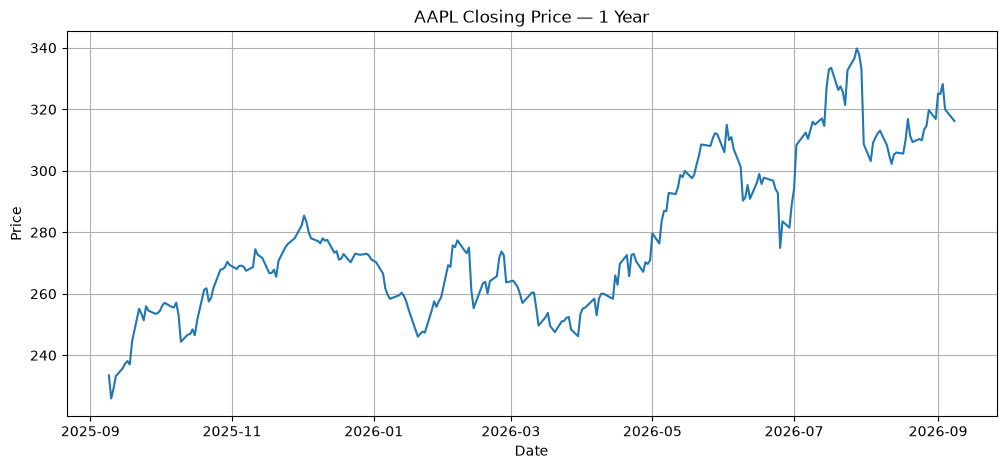

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Close"])
plt.title("AAPL Closing Price — 1 Year")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

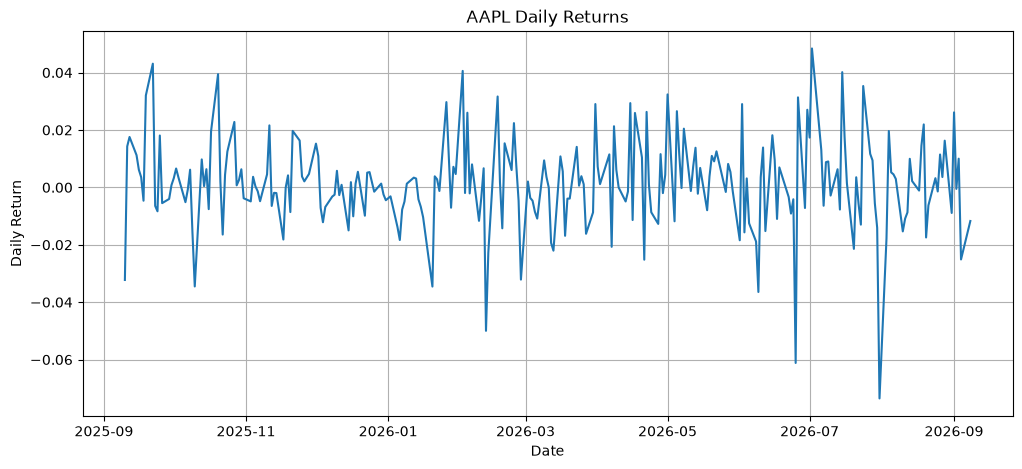

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Daily_Return"])
plt.title("AAPL Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [12]:
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Daily_Return
Date,,,,,,,,
2025-09-09 00:00:00-04:00,236.127759,237.901207,232.501156,233.487518,66313900,0.0,0.0,NaN
2025-09-10 00:00:00-04:00,231.335457,231.564607,225.118417,225.955322,83440800,0.0,0.0,-0.032260
2025-09-11 00:00:00-04:00,226.045010,229.601863,225.815845,229.183411,50208600,0.0,0.0,0.014286
2025-09-12 00:00:00-04:00,228.376401,233.646925,228.177140,233.208557,55824200,0.0,0.0,0.017563
2025-09-15 00:00:00-04:00,236.127756,237.313379,234.165005,235.828857,42699500,0.0,0.0,0.011236


In [13]:
data["MA_20"] = data["Close"].rolling(window=20).mean()
data["MA_50"] = data["Close"].rolling(window=50).mean()

data[["Close", "MA_20", "MA_50"]].tail()

,Close,MA_20,MA_50
Date,,,
2026-09-01 00:00:00-04:00,325.130005,311.279642,312.760703
2026-09-02 00:00:00-04:00,324.959991,311.991040,313.378975
2026-09-03 00:00:00-04:00,328.209991,312.794499,314.086626
2026-09-04 00:00:00-04:00,319.970001,313.139999,314.987768
2026-09-08 00:00:00-04:00,316.220001,313.537999,315.641459


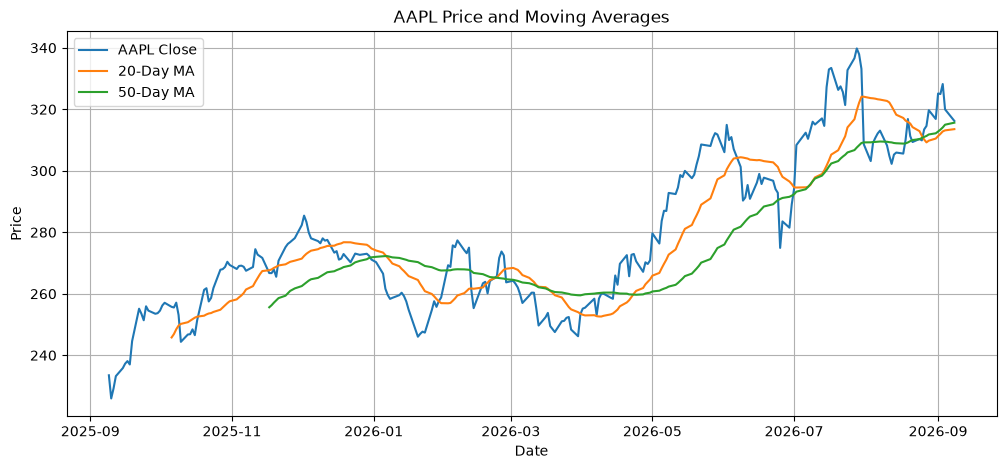

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(data.index, data["Close"], label="AAPL Close")
plt.plot(data.index, data["MA_20"], label="20-Day MA")
plt.plot(data.index, data["MA_50"], label="50-Day MA")

plt.title("AAPL Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
data["Volatility_20"] = data["Daily_Return"].rolling(window=20).std()

data[["Daily_Return", "Volatility_20"]].tail()

,Daily_Return,Volatility_20
Date,,
2026-09-01 00:00:00-04:00,0.026132,0.011868
2026-09-02 00:00:00-04:00,-0.000523,0.011871
2026-09-03 00:00:00-04:00,0.010001,0.011987
2026-09-04 00:00:00-04:00,-0.025106,0.013489
2026-09-08 00:00:00-04:00,-0.011720,0.013279


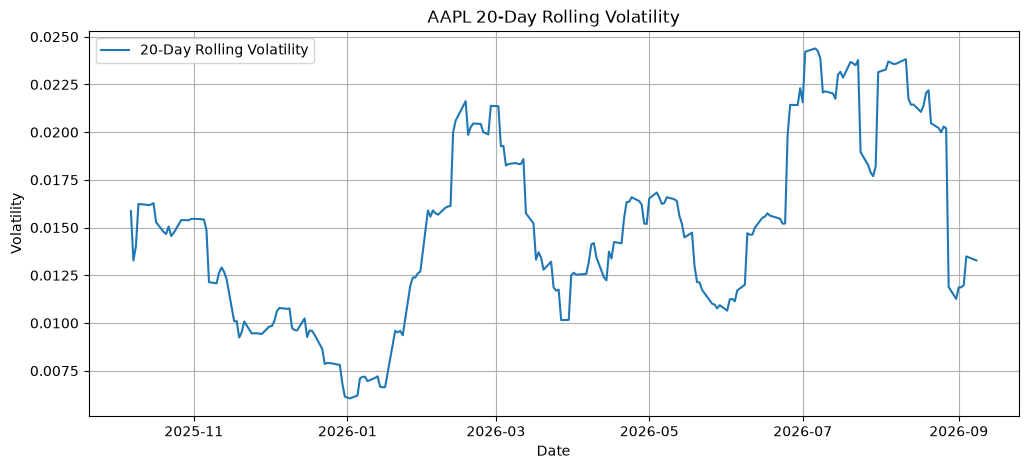

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    data.index,
    data["Volatility_20"],
    label="20-Day Rolling Volatility"
)

plt.title("AAPL 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
annualized_volatility = data["Daily_Return"].std() * np.sqrt(252)

print(f"Annualized Volatility: {annualized_volatility:.2%}")

Annualized Volatility: 25.10%


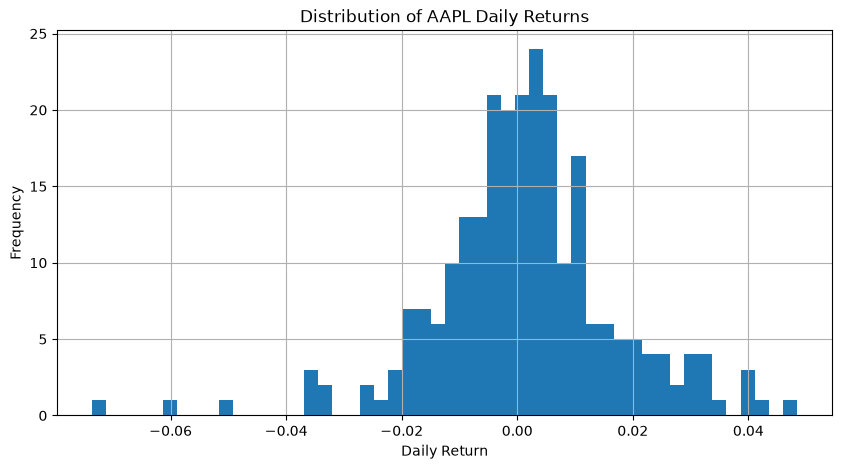

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(
    data["Daily_Return"].dropna(),
    bins=50
)

plt.title("Distribution of AAPL Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [19]:
best_day = data["Daily_Return"].idxmax()
worst_day = data["Daily_Return"].idxmin()

print("Best Trading Day:")
print(best_day.date(), f"{data.loc[best_day, 'Daily_Return']:.2%}")

print("\nWorst Trading Day:")
print(worst_day.date(), f"{data.loc[worst_day, 'Daily_Return']:.2%}")

Best Trading Day:
2026-07-02 4.84%

Worst Trading Day:
2026-07-31 -7.35%


In [20]:
data["Cumulative_Max"] = data["Close"].cummax()

data["Drawdown"] = (
    data["Close"] - data["Cumulative_Max"]
) / data["Cumulative_Max"]

maximum_drawdown = data["Drawdown"].min()

print(f"Maximum Drawdown: {maximum_drawdown:.2%}")

Maximum Drawdown: -13.80%


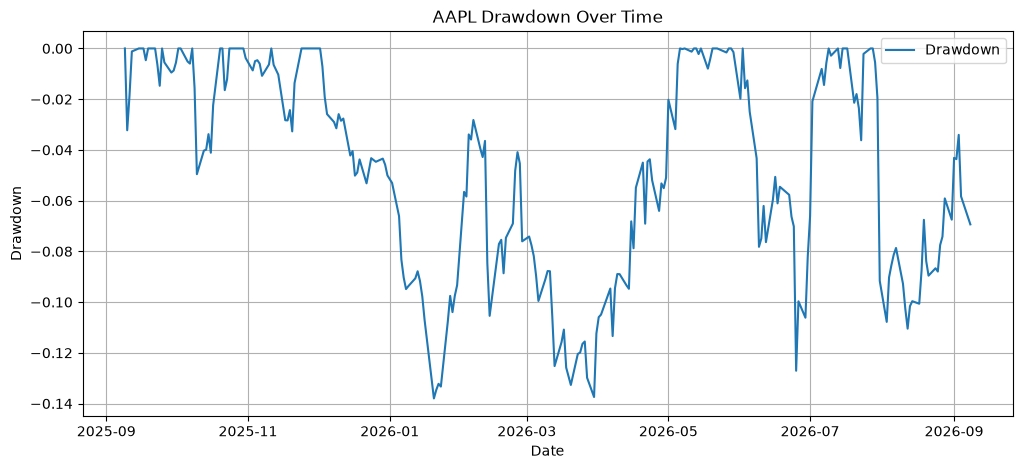

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    data.index,
    data["Drawdown"],
    label="Drawdown"
)

plt.title("AAPL Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
average_daily_return = data["Daily_Return"].mean()
daily_volatility = data["Daily_Return"].std()

sharpe_ratio = (
    average_daily_return / daily_volatility
) * np.sqrt(252)

print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")

Annualized Sharpe Ratio: 1.34


In [23]:
data["Volume_MA_20"] = data["Volume"].rolling(window=20).mean()

data[["Volume", "Volume_MA_20"]].tail()

,Volume,Volume_MA_20
Date,,
2026-09-01 00:00:00-04:00,53167400,40626180.0
2026-09-02 00:00:00-04:00,33776400,39843060.0
2026-09-03 00:00:00-04:00,37225800,39397355.0
2026-09-04 00:00:00-04:00,39606900,39655840.0
2026-09-08 00:00:00-04:00,35423000,39186365.0


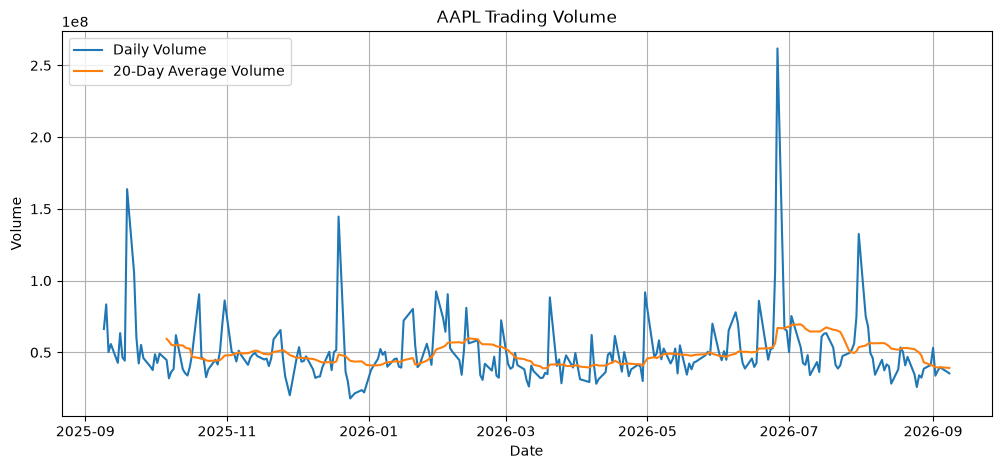

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(
    data.index,
    data["Volume"],
    label="Daily Volume"
)

plt.plot(
    data.index,
    data["Volume_MA_20"],
    label="20-Day Average Volume"
)

plt.title("AAPL Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
data["Volume_Ratio"] = data["Volume"] / data["Volume_MA_20"]

data[["Volume", "Volume_MA_20", "Volume_Ratio"]].tail()

,Volume,Volume_MA_20,Volume_Ratio
Date,,,
2026-09-01 00:00:00-04:00,53167400,40626180.0,1.308698
2026-09-02 00:00:00-04:00,33776400,39843060.0,0.847736
2026-09-03 00:00:00-04:00,37225800,39397355.0,0.944881
2026-09-04 00:00:00-04:00,39606900,39655840.0,0.998766
2026-09-08 00:00:00-04:00,35423000,39186365.0,0.903962


In [26]:
top_volume_days = data.sort_values(
    by="Volume_Ratio",
    ascending=False
)[["Volume", "Volume_MA_20", "Volume_Ratio"]].head(10)

top_volume_days

,Volume,Volume_MA_20,Volume_Ratio
Date,,,
2026-06-26 00:00:00-04:00,261775500,66983485.0,3.908060
2025-12-19 00:00:00-05:00,144632000,48541600.0,2.979547
2026-07-31 00:00:00-04:00,132489100,53667210.0,2.468716
2026-03-20 00:00:00-04:00,88331100,41493415.0,2.128798
2026-04-30 00:00:00-04:00,91848200,43373955.0,2.117589
2025-10-20 00:00:00-04:00,90483000,46127420.0,1.961588
2026-06-25 00:00:00-04:00,107013700,56305730.0,1.900583
2025-10-31 00:00:00-04:00,86167100,47832125.0,1.801448
2026-01-30 00:00:00-05:00,92443400,52000865.0,1.777728


In [28]:
data[["Daily_Return", "Volume_Ratio"]].corr()

,Daily_Return,Volume_Ratio
Daily_Return,1.000000,-0.037734
Volume_Ratio,-0.037734,1.000000
